# Sales sandbox: exploratory analysis

Goal: Which regions drive the drop in average price?

### Load sales CSV and plot units and price

- Reads data/sales.csv with order_date parsed as a date
- Plots units and price per order against order date in one figure
- Two stacked panels share the date axis, since units and price use different scales
- Gaps in the price line are the 6 orders with a missing price

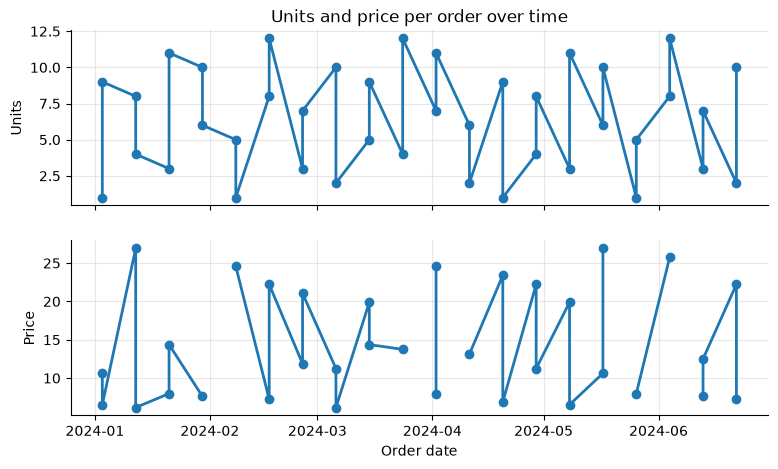

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

SALES_PATH = "../data/sales.csv"

sales = pd.read_csv(SALES_PATH, parse_dates=["order_date"])
sales_by_date = sales.sort_values("order_date")

fig, (ax_units, ax_price) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))

ax_units.plot(sales_by_date["order_date"], sales_by_date["units"], marker="o", linewidth=2)
ax_units.set_ylabel("Units")
ax_units.set_title("Units and price per order over time")

ax_price.plot(sales_by_date["order_date"], sales_by_date["price"], marker="o", linewidth=2)
ax_price.set_ylabel("Price")
ax_price.set_xlabel("Order date")

for ax in (ax_units, ax_price):
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()

### Plot monthly average price by region

- Groups orders by calendar month and region and averages the price
- Missing prices are skipped by the mean, not filled in
- One line per region, so a region driving the drop stands out
- Averaging per month removes the order-to-order zig-zag of the previous chart

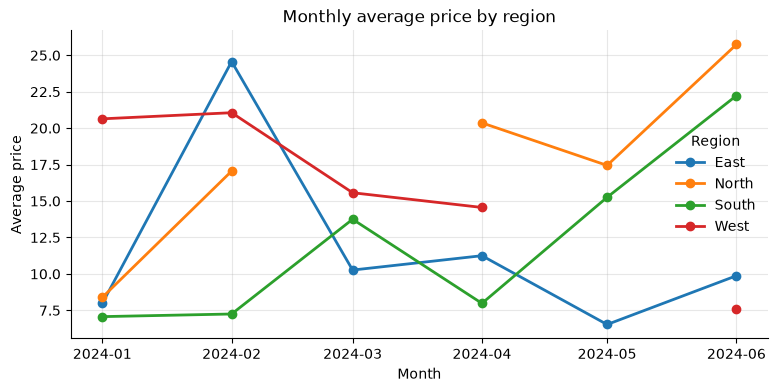

region,East,North,South,West
month,,,,
2024-01-01,7.98,8.39,7.07,20.64
2024-02-01,24.57,17.06,7.25,21.06
2024-03-01,10.26,NaN,13.75,15.57
2024-04-01,11.25,20.36,7.98,14.56
2024-05-01,6.53,17.44,15.26,NaN
2024-06-01,9.88,25.74,22.23,7.61


In [3]:
sales_monthly = sales.assign(month=sales["order_date"].dt.to_period("M").dt.to_timestamp())

avg_price_by_region = (
    sales_monthly.groupby(["month", "region"])["price"]
    .mean()
    .unstack("region")
)

fig, ax = plt.subplots(figsize=(9, 4))
for region in avg_price_by_region.columns:
    ax.plot(avg_price_by_region.index, avg_price_by_region[region], marker="o", linewidth=2, label=region)

ax.set_title("Monthly average price by region")
ax.set_ylabel("Average price")
ax.set_xlabel("Month")
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Region", frameon=False)
plt.show()

avg_price_by_region.round(2)

### Split orders by date with sklearn

- Uses sklearn train_test_split twice: first cuts off test, then splits the rest into train and validation
- shuffle=False keeps time order, so the model never trains on orders newer than those it is scored on
- Validation is 20% and test 10% of all orders (VALIDATION_SHARE, TEST_SHARE); train gets the rest
- The table shows each part's size, date range and missing prices

In [10]:
from sklearn.model_selection import train_test_split

VALIDATION_SHARE = 0.20
TEST_SHARE = 0.10

# shuffle=False keeps time order: the newest orders go to test, then validation
train_and_validation, test = train_test_split(
    sales_by_date, test_size=TEST_SHARE, shuffle=False
)

validation_share_of_rest = VALIDATION_SHARE / (1 - TEST_SHARE)
train, validation = train_test_split(
    train_and_validation, test_size=validation_share_of_rest, shuffle=False
)

split_summary = pd.DataFrame({
    "rows": [len(train), len(validation), len(test)],
    "first_date": [
        train["order_date"].min(),
        validation["order_date"].min(),
        test["order_date"].min(),
    ],
    "last_date": [
        train["order_date"].max(),
        validation["order_date"].max(),
        test["order_date"].max(),
    ],
    "missing_price": [
        train["price"].isna().sum(),
        validation["price"].isna().sum(),
        test["price"].isna().sum(),
    ],
}, index=["train", "validation", "test"])

split_summary

,rows,first_date,last_date,missing_price
train,28,2024-01-03,2024-04-29,4
validation,8,2024-05-08,2024-06-04,2
test,4,2024-06-13,2024-06-22,0


### Fit linear regression of price on units

- Fits price = intercept + slope × units on the training orders that have a price
- Scores it on validation with MAE and R², next to a baseline that always predicts the training mean price
- The test set is left untouched for a final check later
- Uses numpy polyfit because scikit-learn is not installed

In [5]:
import numpy as np

train_priced = train.dropna(subset=["price"])
validation_priced = validation.dropna(subset=["price"])

slope, intercept = np.polyfit(train_priced["units"], train_priced["price"], deg=1)

validation_pred = intercept + slope * validation_priced["units"]
baseline_pred = train_priced["price"].mean()

model_error = validation_priced["price"] - validation_pred
baseline_error = validation_priced["price"] - baseline_pred

validation_spread = validation_priced["price"] - validation_priced["price"].mean()
model_r2 = 1 - (model_error**2).sum() / (validation_spread**2).sum()

model_summary = pd.Series({
    "train_rows": len(train_priced),
    "validation_rows": len(validation_priced),
    "train_correlation": train_priced["units"].corr(train_priced["price"]),
    "intercept": intercept,
    "slope_per_unit": slope,
    "validation_mae_model": model_error.abs().mean(),
    "validation_mae_mean_baseline": baseline_error.abs().mean(),
    "validation_r2_model": model_r2,
})

model_summary.round(3)

train_rows                      24.000
validation_rows                  5.000
train_correlation                0.233
intercept                       11.445
slope_per_unit                   0.452
validation_mae_model             7.437
validation_mae_mean_baseline     7.184
validation_r2_model             -0.030
dtype: float64

### Drop missing prices and add revenue column

- Removes the orders with no price from the full sales data, since revenue needs a price
- Adds revenue = units × price for each order
- Uses the full data, not the train/validation/test splits, because this is exploration
- The first rows let you check revenue by hand

In [ ]:
sales_clean = sales.dropna(subset=["price"])
sales_clean = sales_clean.assign(revenue=sales_clean["units"] * sales_clean["price"])

sales_clean.head()